<a href="https://colab.research.google.com/github/AbishekMishra183/DataScience_ML_journey/blob/main/DataScience_day33(ANN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Artificial Neural Network (ANN) – Theory

---

## 📌 What is an Artificial Neural Network?

An **Artificial Neural Network (ANN)** is a machine learning model inspired by the structure and function of the human brain. It is made up of **neurons** (nodes) organized in **layers** and connected by **weights**. ANNs are capable of learning complex patterns from data and are commonly used in:

- **Classification** (e.g., spam detection, disease diagnosis)
- **Regression** (e.g., predicting prices or sales)
- **Pattern recognition** (e.g., image recognition, speech recognition)

---

## 🧬 Structure of ANN

An ANN typically has three types of layers:

1. **Input Layer**: Receives the input features.
2. **Hidden Layers**: Perform transformations using weights, biases, and activation functions.
3. **Output Layer**: Produces the final result (e.g., class label or predicted value).



Each **neuron** receives inputs, applies a **weighted sum**, adds a **bias**, and passes the result through an **activation function**.

---

## 🔁 How ANN Learns

### 1. **Forward Propagation**
- Data flows from input → output layer.
- Each neuron computes a weighted sum and applies an **activation function**.
- Final output is compared to the actual target.

### 2. **Loss Function**
- Measures the error between predicted and actual values.
- Common loss functions:
  - **Binary Crossentropy** (for binary classification)
  - **Categorical Crossentropy** (for multi-class classification)
  - **Mean Squared Error (MSE)** (for regression)

### 3. **Backpropagation**
- The error is propagated backward to update the weights and biases.
- Uses **Gradient Descent** to minimize the loss.

---

## 🧮 Activation Functions

Activation functions introduce non-linearity, enabling ANNs to learn complex patterns.

| Function   | Formula                        | Use Case                         |
|------------|--------------------------------|----------------------------------|
| Sigmoid    | `1 / (1 + e^-x)`               | Binary classification            |
| ReLU       | `max(0, x)`                    | Hidden layers                    |
| Softmax    | `e^x / sum(e^x)`               | Multi-class classification       |
| Tanh       | `(e^x - e^-x)/(e^x + e^-x)`    | Output between -1 and 1          |

---

## 📉 Loss Functions

Loss functions quantify how well or poorly the model performs.

- **Binary Crossentropy**: For binary classification
- **Categorical Crossentropy**: For multi-class classification
- **Mean Squared Error (MSE)**: For regression problems

---

## ⚙️ Optimizers

Optimizers update the model weights to reduce the loss.

- **SGD (Stochastic Gradient Descent)**
- **Adam (Adaptive Moment Estimation)** — commonly used

---

## ✅ Summary

| Component        | Description                                                   |
|------------------|---------------------------------------------------------------|
| Input Layer      | Takes features from dataset                                   |
| Hidden Layers    | Perform computations and pattern learning                     |
| Output Layer     | Produces the prediction result                                |
| Activation       | Adds non-linearity (e.g., ReLU, Sigmoid, Softmax)             |
| Loss Function    | Measures error between prediction and actual value            |
| Optimizer        | Updates weights to reduce loss                                |
| Framework        | TensorFlow / Keras                                            |

---

## 🧪 Applications of ANN

- **Medical Diagnosis**: Predicting diseases
- **Finance**: Fraud detection, stock forecasting
- **Image & Speech Recognition**
- **Recommender Systems**
- **Self-driving Cars**


In [ ]:
# Data handling and preprocessing
import pandas as pd
import numpy as np

# For train-test splitting and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TensorFlow for ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


In [ ]:
# Load the dataset from a URL
df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv', header=None)

# Set column names
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
              'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Display first 5 rows
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
X = df.drop('Outcome', axis=1)  # Features
y = df['Outcome']               # Target


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)


In [ ]:
scaler = StandardScaler()

# Fit and transform training set
X_train = scaler.fit_transform(X_train)

# Only transform the test set
X_test = scaler.transform(X_test)


In [ ]:
# Build the model
model = Sequential()

# Hidden Layer 1
model.add(Dense(16, input_dim=8, activation='relu'))

# Hidden Layer 2
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [ ]:
history = model.fit(X_train, y_train,
                    validation_split=0.1,
                    epochs=100,
                    batch_size=16,
                    verbose=1)


Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.3496 - loss: 0.8605 - val_accuracy: 0.5000 - val_loss: 0.7161
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4505 - loss: 0.7273 - val_accuracy: 0.5484 - val_loss: 0.6643
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6608 - loss: 0.6774 - val_accuracy: 0.6452 - val_loss: 0.6325
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6563 - loss: 0.6518 - val_accuracy: 0.7097 - val_loss: 0.6093
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7146 - loss: 0.6163 - val_accuracy: 0.7258 - val_loss: 0.5836
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7314 - loss: 0.6001 - val_accuracy: 0.7419 - val_loss: 0.5600
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7325 - loss: 0.5711 - val_accuracy: 0.7419 - val_loss: 0.5414
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7572 - loss: 0.5408 - val_accuracy: 0.7419 - 

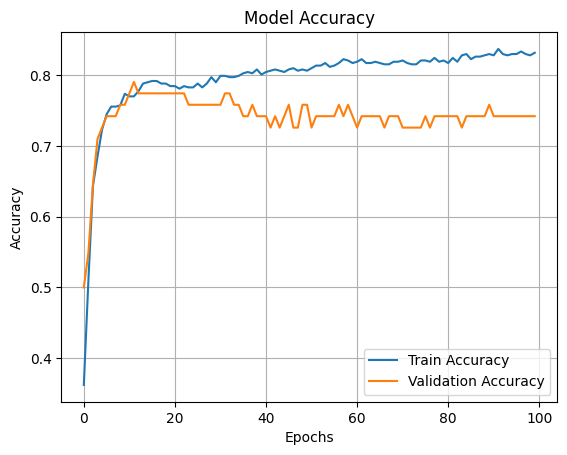

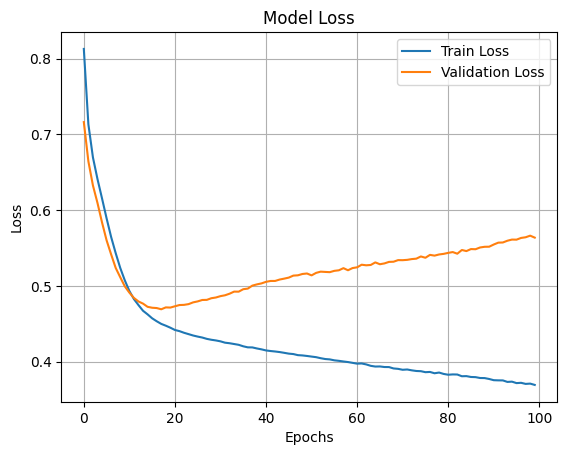

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7615 - loss: 0.6005
Test Accuracy: 77.92%


In [ ]:
# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert to binary predictions
y_pred = (y_pred_probs > 0.5).astype(int)

# Display first 10 predictions
print("Predictions:", y_pred[:10].flatten())
print("True labels:", y_test.values[:10])


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Predictions: [0 0 0 0 0 1 0 1 1 0]
True labels: [0 0 0 0 0 0 0 0 0 0]
